In [1]:
import tensorflow as tf
from student_model import build_student_model
from tensorflow.keras.datasets import cifar10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 190s 1us/step


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train,y_train,test_size = 0.2, random_state = 41, stratify = y_train)

In [5]:
input_shape = x_train.shape[1:]
input_shape

(32, 32, 3)

In [6]:
student_model = build_student_model(input_shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,746 (252.91 KB)

 Trainable params: 64,650 (252.54 KB)

 Non-trainable params: 96 (384.00 B)

In [7]:
student_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,746 (252.91 KB)

 Trainable params: 64,650 (252.54 KB)

 Non-trainable params: 96 (384.00 B)

In [8]:
from tensorflow.keras.models import load_model

teacher_model = load_model('teacher_model.h5')
teacher_model.trainable = False
student_model.trainable = True

In [9]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import KLDivergence

ce_loss = SparseCategoricalCrossentropy(from_logits = True)
kl_loss = KLDivergence()
optimizer = Adam(learning_rate=0.003)

temperature = 3
alpha = 0.1
batch_size = 64


train_dataset = tf.data.Dataset.from_tensor_slices((x_train,y_train))
train_dataset = train_dataset.shuffle(len(x_train), reshuffle_each_iteration = True).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((x_val,y_val))
val_dataset = val_dataset.batch(batch_size)

history = {

    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [10]:
epochs = 40


for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}\n")

    train_loss_metric = tf.keras.metrics.Mean()
    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            student_logits = student_model(x_batch, training=True)
            teacher_logits = teacher_model(x_batch, training=False)

            hard_loss = ce_loss(y_batch, student_logits)

            teacher_soft = tf.nn.softmax(teacher_logits / temperature, axis=1)
            student_soft = tf.nn.softmax(student_logits / temperature, axis=1)
            soft_loss = kl_loss(teacher_soft, student_soft) * (temperature ** 2)

            loss = alpha * hard_loss + (1 - alpha) * soft_loss

        gradients = tape.gradient(loss, student_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, student_model.trainable_variables))

        train_loss_metric.update_state(loss)
        train_acc_metric.update_state(y_batch, student_logits)

    train_loss = train_loss_metric.result().numpy()
    train_acc = train_acc_metric.result().numpy()


    val_loss_metric = tf.keras.metrics.Mean()
    val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_val_batch, y_val_batch in val_dataset:
        val_logits = student_model(x_val_batch, training=False)

        val_loss_batch = ce_loss(y_val_batch, val_logits)
        val_loss_metric.update_state(val_loss_batch)
        val_acc_metric.update_state(y_val_batch, val_logits)

    val_loss = val_loss_metric.result().numpy()
    val_acc = val_acc_metric.result().numpy()


    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Loss: {train_loss:.4f} - Accuracy: {train_acc:.4f} - Validation Loss: {val_loss:.4f} - Validation Accuracy: {val_acc:.4f}")

Epoch 1/40

Loss: 6.0391 - Accuracy: 0.5052 - Validation Loss: 1.6638 - Validation Accuracy: 0.5921
Epoch 2/40

Loss: 4.2649 - Accuracy: 0.6198 - Validation Loss: 1.4813 - Validation Accuracy: 0.6260
Epoch 3/40

Loss: 3.5866 - Accuracy: 0.6672 - Validation Loss: 1.1298 - Validation Accuracy: 0.6783
Epoch 4/40

Loss: 3.1597 - Accuracy: 0.6964 - Validation Loss: 1.1305 - Validation Accuracy: 0.6807
Epoch 5/40

Loss: 2.8998 - Accuracy: 0.7159 - Validation Loss: 1.0109 - Validation Accuracy: 0.7153
Epoch 6/40

Loss: 2.7437 - Accuracy: 0.7257 - Validation Loss: 1.1597 - Validation Accuracy: 0.7015
Epoch 7/40

Loss: 2.5928 - Accuracy: 0.7388 - Validation Loss: 1.0795 - Validation Accuracy: 0.7157
Epoch 8/40

Loss: 2.4953 - Accuracy: 0.7449 - Validation Loss: 0.9446 - Validation Accuracy: 0.7420
Epoch 9/40

Loss: 2.3916 - Accuracy: 0.7510 - Validation Loss: 0.9179 - Validation Accuracy: 0.7375
Epoch 10/40

Loss: 2.3566 - Accuracy: 0.7572 - Validation Loss: 1.7478 - Validation Accuracy: 0.5947

Text(0, 0.5, 'loss')

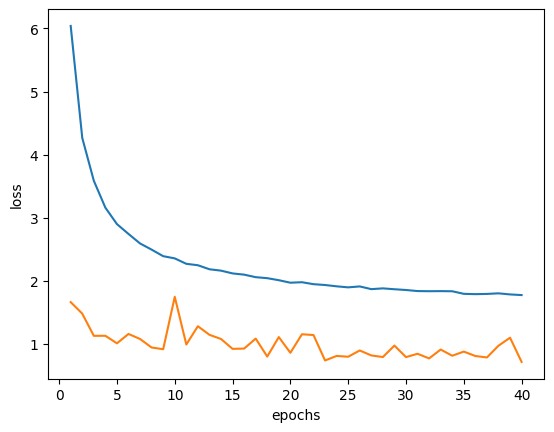

In [16]:
from matplotlib import pyplot as plt

epochs = range(1,len(history['train_loss'])+1)
plt.plot(epochs, history['train_loss'])
plt.plot(epochs, history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')

Text(0, 0.5, 'acc')

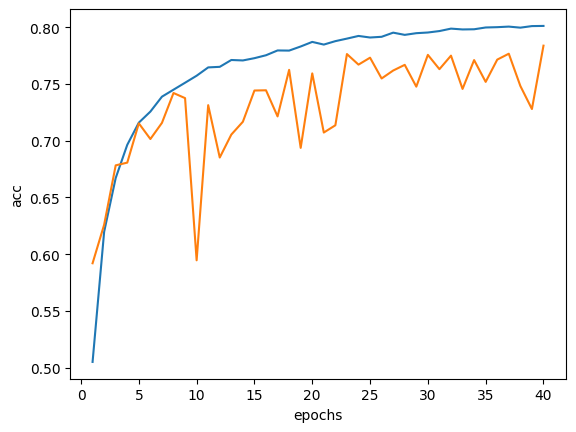

In [18]:
epochs = range(1,len(history['train_acc'])+1)
plt.plot(epochs, history['train_acc'])
plt.plot(epochs, history['val_acc'])
plt.xlabel('epochs')
plt.ylabel('acc')